<a href="https://colab.research.google.com/github/DanilKopanev/data-analyst-portfolio/blob/main/yandex-praktikum/hospital_analysis/hospital_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ длительности госпитализации в федеральном медцентре

<table style="border:2px solid #8e44ad; border-radius:8px; background-color:#f8f1ff; width:100%;">
  <tr>
    <td style="padding:12px 16px;">

<b>Инсайты за 30 секунд</b>

- Медианная длительность госпитализации — 7 дней, средняя — около 8.7.  
- В среднем пациенты не лежат дольше 10 дней.  
- Плановые пациенты значимо дольше в стационаре, чем экстренные.
    </td>
  </tr>
</table>


##1. Описание задачи и данных

---

###1.1. Цель исследования

**Цель исследования** — проанализировать данные федерального медицинского центра ФГБОУ ВО СПбГПМУ и понять, какие факторы влияют на длительность госпитализации пациентов, а также на время от поступления в отделение до выписки.

Отдельное внимание уделяется сравнению длительности лечения между разными отделениями и группами пациентов (плановые и экстренные случаи).

###1.2. Описание данных

В работе используется таблица `hospital.csv`, содержащая информацию о госпитализациях пациентов.

Основные поля:

- `ДАТА_ПОСТУПЛЕНИЯ` — дата поступления пациента в отделение;  
- `ДАТА_ВЫПИСКИ` — дата выписки пациента из отделения;  
- `УНИКАЛЬНЫЙ_ID` — идентификатор пациента;  
- `НОМЕР_ИБ`, `ШИФР` — служебные системные поля;  
- `РЕГИОН` — регион проживания пациента;  
- `ПЛАТЕЛЬЩИК` — наименование плательщика;  
- `ИСТОЧНИК_ФИНАНСИРОВАНИЯ` — источник оплаты (ОМС или другой вариант);  
- `ОТДЕЛЕНИЕ` — название отделения;  
- `ПРОФИЛЬ` — профиль отделения (например, терапия, хирургия);  
- `КОЙКО_ДНИ` — количество дней лечения в стационаре;  
- `ПЛАНОВО_ЭКСТРЕННО` — тип поступления (плановое или экстренное);  
- `КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ`, `КОД_МКБ_ПРИ_ВЫПИСКЕ` — диагнозы по МКБ при поступлении и при выписке.

| Поле (рус.)                      | Поле (англ.)             | Описание |
|----------------------------------|--------------------------|-----------|
| Дата поступления                 | income_date              | Дата поступления пациента в отделение |
| Дата выписки                     | outcome_date             | Дата выписки пациента из отделения |
| Уникальный ID                    | user_id                  | Идентификатор пациента |
| Номер ИБ                         | is_num                   | Системное поле (номер информационной безопасности) |
| Шифр                             | code                     | Системное поле |
| Регион                           | region                   | Регион проживания пациента |
| Плательщик                       | payer                    | Наименование плательщика |
| Источник финансирования          | fin_source               | ОМС или другой вариант |
| Отделение                        | dept                     | Название отделения |
| Профиль                          | profile                  | Профиль отделения (терапия, хирургия и т.д.) |
| Койко-дни                        | bed_days                 | Количество дней лечения в стационаре |
| Планово/экстренно                | is_plan                  | Поступил планово или экстренно |
| Код МКБ при поступлении          | income_mkb               | Код диагноза при поступлении |
| Код МКБ при выписке              | outcome_mkb              | Код диагноза при выписке |

###1.3. План работы

- Подготовить данные: переименовать столбцы, проверить пропуски, типы данных и дубликаты.  
- Провести EDA: изучить распределение длительности госпитализации, отделения‑лидеры и динамику поступлений.  
- Проверить три статистические гипотезы о средней длительности госпитализации и её различиях между группами пациентов.

**Содержание**

1. [Описание задачи и данных](#описание-задачи-и-данных)  
   1.1. [Цель исследования](#цель-исследования)  
   1.2. [Описание данных](#описание-данных)  
   1.3. [План работы](#план-работы)  
2. [Подготовка данных](#подготовка-данных)  
   2.1. [Загрузка датасета](#загрузка-датасета)  
   2.2. [Переименование столбцов](#переименование-столбцов)  
   2.3. [Анализ и обработка пропусков](#анализ-и-обработка-пропусков)  
   2.4. [Приведение типов данных](#приведение-типов-данных)  
   2.5. [Проверка на дубликаты](#проверка-на-дубликаты)  
3. [Исследовательский анализ данных (EDA)](#исследовательский-анализ-данных-eda)  
   3.1. [Распределение длительности госпитализации](#распределение-длительности-госпитализации)  
   3.2. [Средняя длительность по отделениям (топ‑10)](#средняя-длительность-по-отделениям-топ‑10)  
   3.3. [Динамика госпитализаций по месяцам и годам](#динамика-госпитализаций-по-месяцам-и-годам)  
4. [Проверка статистических гипотез](#проверка-статистических-гипотез)  
   4.1. [Проверка отклонения от стандартного срока 7 дней](#проверка-отклонения-от-стандартного-срока-7-дней)
   4.2. [Проверка гипотезы «средняя длительность > 10 дней»](#проверка-гипотезы-средняя-длительность--10-дней)
   4.3. [Сравнение плановых и экстренных пациентов](#сравнение-плановых-и-экстренных-пациентов)  
5. [Выводы](#выводы)  
   5.1. [Обзор проделанной работы](#обзор-проделанной-работы)  
   5.2. [Ключевые выводы](#ключевые-выводы)  
   5.3. [Рекомендации для заказчика](#рекомендации-для-заказчика)

## 2. Подготовка данных
---

###2.1. Загрузка данных  

> Подключим библиотеки для анализа данных и визуализаций.

In [103]:
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import missingno as msno
    import plotly.express as px
    from scipy import stats as st
except ImportError as e:
    print(f'Не удалось импортировать библиотеку: {e}')

plt.rcParams['axes.grid'] = False


In [104]:
hospital = pd.read_csv('hospital.csv', sep=',')

hospital.head()

,ДАТА_ПОСТУПЛЕНИЯ,ДАТА_ВЫПИСКИ,УНИКАЛЬНЫЙ_ID,НОМЕР_ИБ,ШИФР,РЕГИОН,ПЛАТЕЛЬЩИК,ИСТОЧНИК_ФИНАНСИРОВАНИЯ,ОТДЕЛЕНИЕ,ПРОФИЛЬ,КОЙКО_ДНИ,ПЛАНОВО_ЭКСТРЕННО,КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ,КОД_МКБ_ПРИ_ВЫПИСКЕ
0,01.01.2019,10.01.2019,858042000,1,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Микрохирургическое отделение,Сосудистой хирургии,10.0,Экстренная,S61.7,S66.4
1,01.01.2019,01.01.2019,993109000,3,5.13.1,NaN,"СПб филиал ООО ""СМК РЕСО - Мед""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
2,01.01.2019,01.01.2019,993111000,4,5.12.1,NaN,"ООО ""Капитал Медицинское Страхование""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
3,01.01.2019,07.01.2019,993110000,2,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Инфекционное отделение №1,Инфекционные,7.0,Экстренная,B27.9,J03.9
4,01.01.2019,05.01.2019,987185000,5,1.1.1,NaN,Коммерческие,Наличный расчет,ПЦ Акушерское физиологическое отделение,Для беременных и рожениц,5.0,Плановая,O42.9,O82.1


In [105]:

hospital.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125261 entries, 0 to 125260
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   ДАТА_ПОСТУПЛЕНИЯ         125261 non-null  object 
 1   ДАТА_ВЫПИСКИ             125261 non-null  object 
 2   УНИКАЛЬНЫЙ_ID            125261 non-null  int64  
 3   НОМЕР_ИБ                 125261 non-null  int64  
 4   ШИФР                     125261 non-null  object 
 5   РЕГИОН                   56391 non-null   object 
 6   ПЛАТЕЛЬЩИК               125261 non-null  object 
 7   ИСТОЧНИК_ФИНАНСИРОВАНИЯ  125261 non-null  object 
 8   ОТДЕЛЕНИЕ                125261 non-null  object 
 9   ПРОФИЛЬ                  125261 non-null  object 
 10  КОЙКО_ДНИ                125261 non-null  float64
 11  ПЛАНОВО_ЭКСТРЕННО        125261 non-null  object 
 12  КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ  125253 non-null  object 
 13  КОД_МКБ_ПРИ_ВЫПИСКЕ      125257 non-null  object 
dtypes: f

- Датасет `hospital` содержит 125 261 запись о госпитализациях и 14 полей: даты поступления и выписки, идентификаторы, регион, плательщик, источник финансирования, отделение, профиль, количество койко-дней, тип поступления и диагнозы по МКБ.
- Большинство столбцов имеют строковый тип, числовым является показатель `КОЙКО_ДНИ` и идентификаторы.
- Существенные пропуски есть только в поле `РЕГИОН`, единичные — в кодах МКБ.


###2.2. Переименование столбцов

In [106]:
columns_mapping = {
    'ДАТА_ПОСТУПЛЕНИЯ': 'income_date',
    'ДАТА_ВЫПИСКИ': 'outcome_date',
    'УНИКАЛЬНЫЙ_ID': 'user_id',
    'НОМЕР_ИБ': 'is_num',
    'ШИФР': 'code',
    'РЕГИОН': 'region',
    'ПЛАТЕЛЬЩИК': 'payer',
    'ИСТОЧНИК_ФИНАНСИРОВАНИЯ': 'fin_source',
    'ОТДЕЛЕНИЕ': 'dept',
    'ПРОФИЛЬ': 'profile',
    'КОЙКО_ДНИ': 'bed_days',
    'ПЛАНОВО_ЭКСТРЕННО': 'is_plan',
    'КОД_МКБ_ПРИ_ПОСТУПЛЕНИИ': 'income_mkb',
    'КОД_МКБ_ПРИ_ВЫПИСКЕ': 'outcome_mkb'
}

hospital = hospital.rename(columns=columns_mapping)

hospital.head()

,income_date,outcome_date,user_id,is_num,code,region,payer,fin_source,dept,profile,bed_days,is_plan,income_mkb,outcome_mkb
0,01.01.2019,10.01.2019,858042000,1,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Микрохирургическое отделение,Сосудистой хирургии,10.0,Экстренная,S61.7,S66.4
1,01.01.2019,01.01.2019,993109000,3,5.13.1,NaN,"СПб филиал ООО ""СМК РЕСО - Мед""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
2,01.01.2019,01.01.2019,993111000,4,5.12.1,NaN,"ООО ""Капитал Медицинское Страхование""",ОМС,Хирургическое отделение №3,Гнойные хирургические,1.0,Экстренная,K37,K63.8
3,01.01.2019,07.01.2019,993110000,2,5.4.1,NaN,"ОАО ""ГСМК"" СПб",ОМС,Инфекционное отделение №1,Инфекционные,7.0,Экстренная,B27.9,J03.9
4,01.01.2019,05.01.2019,987185000,5,1.1.1,NaN,Коммерческие,Наличный расчет,ПЦ Акушерское физиологическое отделение,Для беременных и рожениц,5.0,Плановая,O42.9,O82.1


###2.3. Анализ и обработка пропусков

In [107]:
hospital.isnull().sum().sort_values(ascending=False)


,0
region,68870
income_mkb,8
outcome_mkb,4
user_id,0
outcome_date,0
income_date,0
code,0
is_num,0
payer,0
fin_source,0


In [108]:
hospital_info = pd.DataFrame({
    'DataType': hospital.dtypes,
    'MissingValues': hospital.isnull().sum(),
    'UniqueValues': hospital.nunique()
}).sort_values(by='MissingValues', ascending=False)

hospital_info['MissingValuesRatio'] = (
    hospital_info['MissingValues'] / len(hospital)
).round(2)

hospital_info

,DataType,MissingValues,UniqueValues,MissingValuesRatio
region,object,68870,142,0.55
income_mkb,object,8,3117,0.00
outcome_mkb,object,4,2779,0.00
user_id,int64,0,77019,0.00
outcome_date,object,0,1862,0.00
income_date,object,0,1825,0.00
code,object,0,88,0.00
is_num,int64,0,42243,0.00
payer,object,0,60,0.00
fin_source,object,0,8,0.00


<Figure size 1000x400 with 0 Axes>

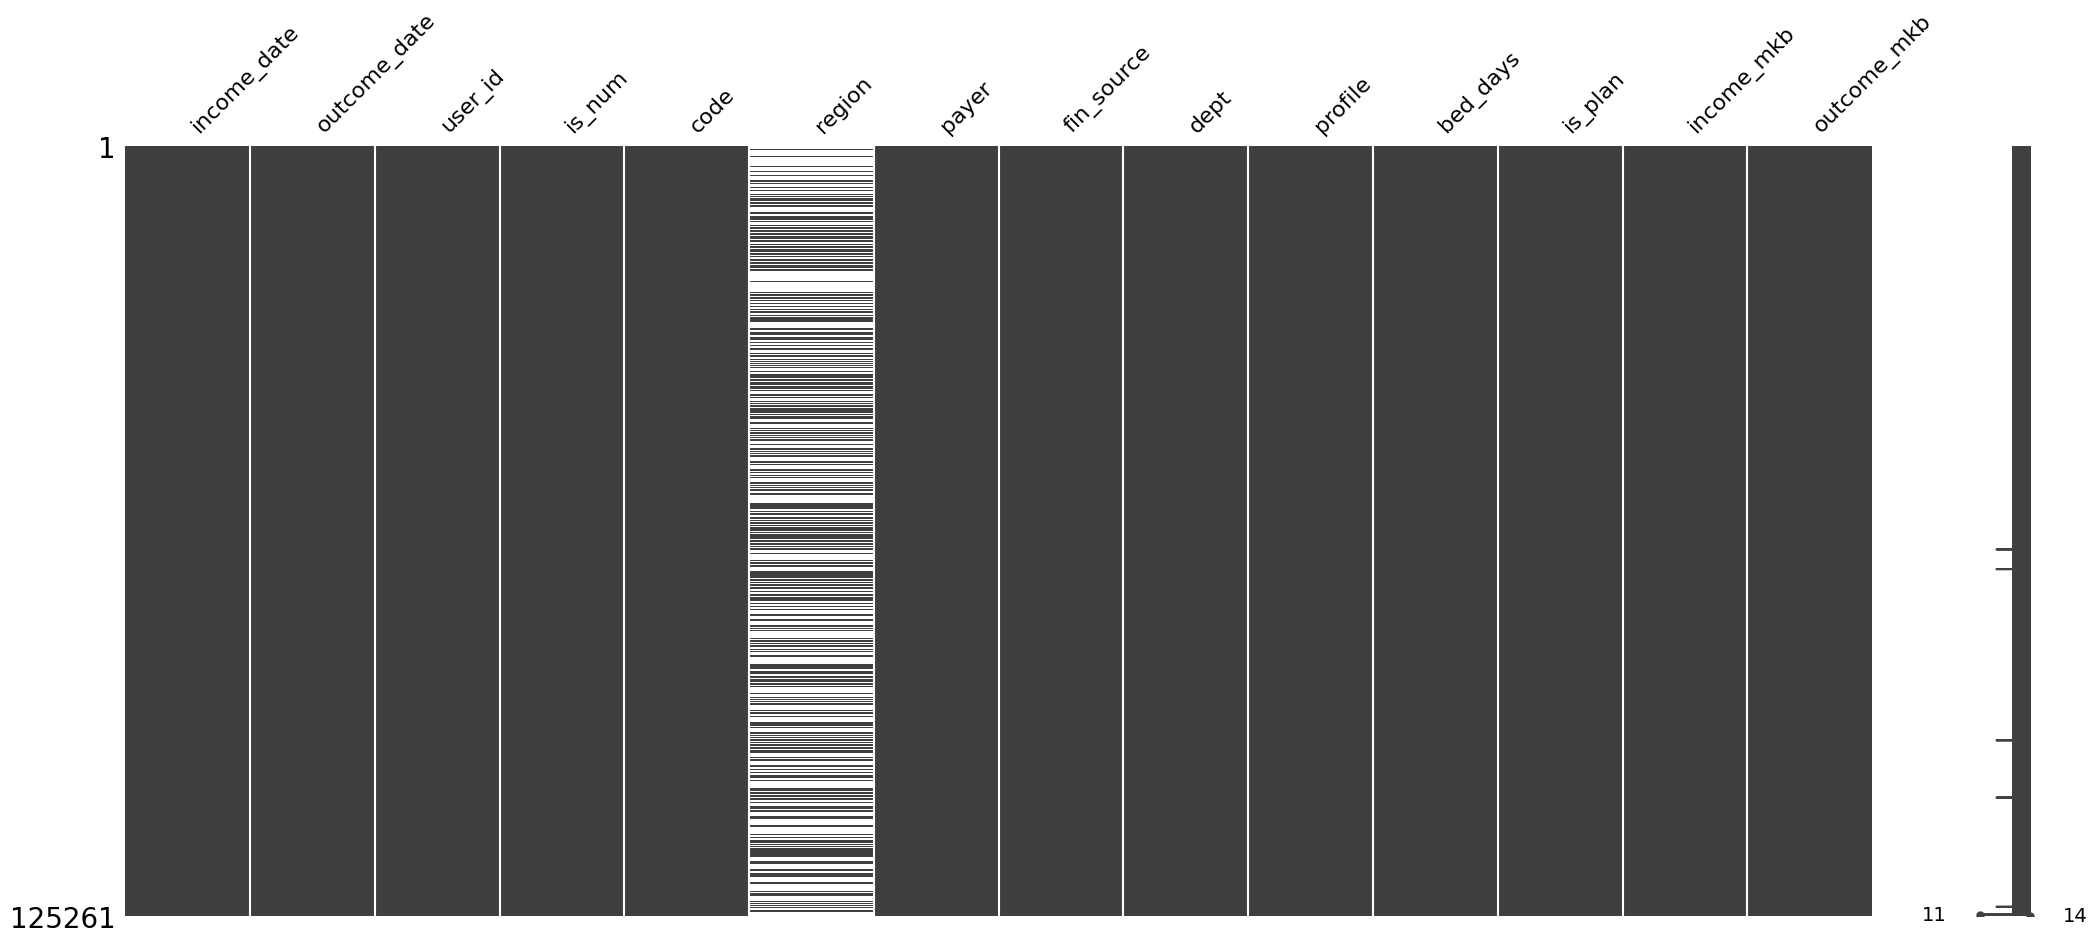

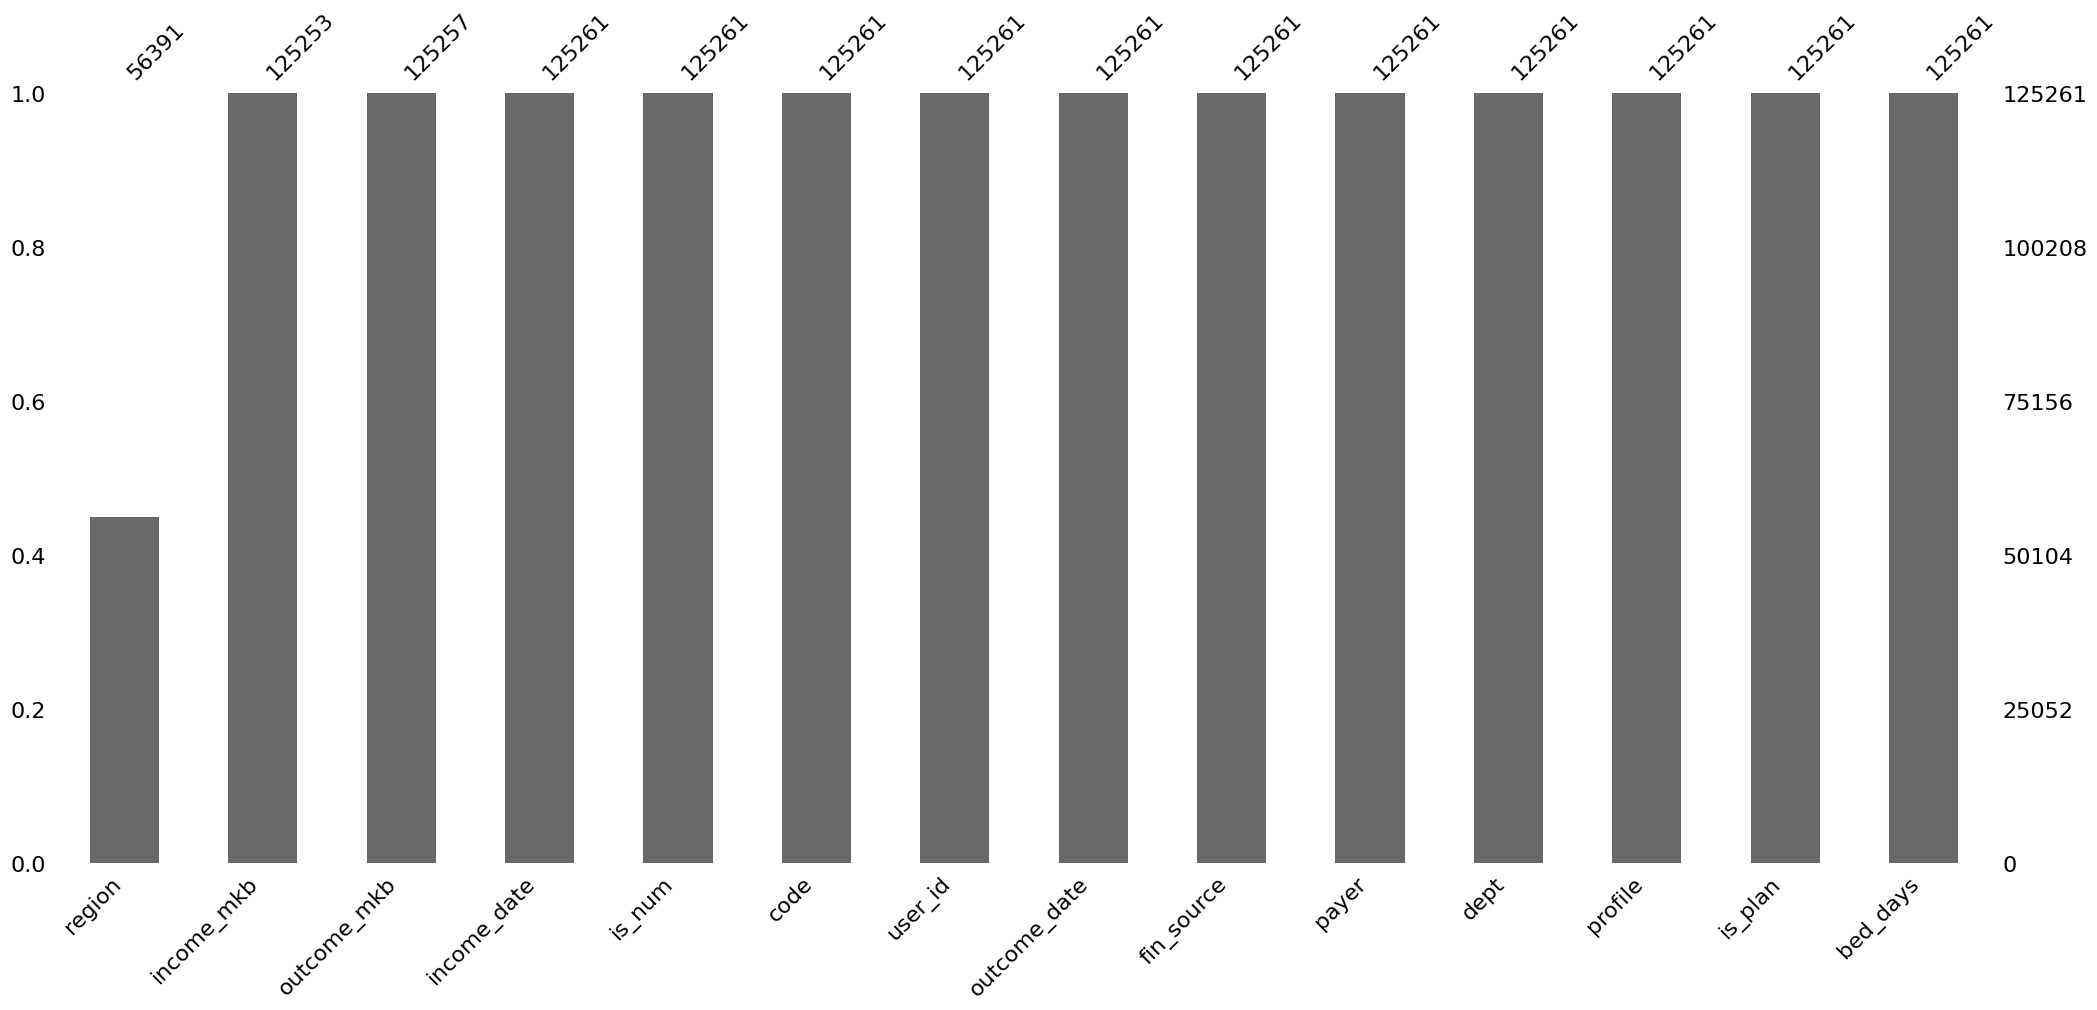

In [109]:
plt.figure(figsize=(10, 4))
msno.matrix(hospital)
plt.show()

plt.figure(figsize=(10, 4))
msno.bar(hospital, sort='ascending')
plt.show()


In [110]:
# Удаляем строки с пропусками в кодах МКБ (их доля мала)
hospital = hospital.dropna(subset=['income_mkb', 'outcome_mkb'])

# Удаляем столбец region: восстановить значения невозможно,
# а пропусков слишком много
hospital = hospital.drop(columns=['region'])

# Проверяем, что пропусков больше нет
hospital.isnull().sum().sort_values(ascending=False)


,0
income_date,0
outcome_date,0
user_id,0
is_num,0
code,0
payer,0
fin_source,0
dept,0
profile,0
bed_days,0


- Основной объём пропусков приходился на столбец `region`, а также на поля `income_mkb` и `outcome_mkb`, однако доля пропусков в кодах МКБ была незначительной.
- Для дальнейшего анализа строки с отсутствующими кодами диагнозов были удалены, а столбец `region` исключён из датафрейма из‑за большого числа пропусков и отсутствия возможности корректного восстановления значений. После обработки в данных не осталось пропусков.

###2.4. Приведение типов данных  

In [111]:
# Посмотрим, сколько памяти занимает датафрейм до оптимизации
mem_before = hospital.memory_usage(deep=True).sum() / 1024**2  # в МБ
print(f'Память до приведения типов: {mem_before:.2f} MB')

Память до приведения типов: 115.53 MB


In [112]:
hospital['income_date'] = pd.to_datetime(
    hospital['income_date'],
    format='%d.%m.%Y'
)
hospital['outcome_date'] = pd.to_datetime(
    hospital['outcome_date'],
    format='%d.%m.%Y'
)

In [113]:
hospital['bed_days'] = hospital['bed_days'].astype('int64')

hospital['user_id'] = hospital['user_id'].astype('int64')
hospital['is_num'] = hospital['is_num'].astype('int64')


In [114]:
cat_cols = [
    'fin_source',
    'dept',
    'profile',
    'is_plan',
    'payer',
    'region'
]

for col in cat_cols:
    if col in hospital.columns:
        hospital[col] = hospital[col].astype('category')


In [115]:
hospital.dtypes


,0
income_date,datetime64[ns]
outcome_date,datetime64[ns]
user_id,int64
is_num,int64
code,object
payer,category
fin_source,category
dept,category
profile,category
bed_days,int64


In [116]:
mem_after = hospital.memory_usage(deep=True).sum() / 1024**2  # в МБ

abs_save = mem_before - mem_after
rel_save = abs_save / mem_before * 100

print(f'Память до приведения типов: {mem_before:.2f} MB')
print(f'Память после приведения типов: {mem_after:.2f} MB')
print(f'Абсолютная экономия памяти: {abs_save:.2f} MB')
print(f'Относительная экономия памяти: {rel_save:.2f}%')


Память до приведения типов: 115.53 MB
Память после приведения типов: 25.84 MB
Абсолютная экономия памяти: 89.70 MB
Относительная экономия памяти: 77.64%


- После приведения типов данных датафрейм **hospital** стал заметно компактнее по использованию памяти. Объём памяти снизился с 115.53 MB до 25.84 MB, то есть на 89.70 MB, что составляет 77.64% от исходного объёма.
- Это произошло за счёт преобразования текстовых дат в тип `datetime`, числовых признаков в целочисленный формат `int64`, а категориальных признаков — в тип `category`, что сделало данные более эффективными по памяти и удобными для последующего анализа.

###2.5. Анализ и обработка дубликатов

In [117]:
# Выделим все полные дубликаты (по всем столбцам)
hospital_full_duplicates = hospital[hospital.duplicated(keep=False)]

# Посмотрим, сколько полных дубликатов есть в датасете
hospital_full_duplicates.shape

(8820, 13)

In [118]:
hospital_full_duplicates.head()

,income_date,outcome_date,user_id,is_num,code,payer,fin_source,dept,profile,bed_days,is_plan,income_mkb,outcome_mkb
550,2019-01-14,2019-01-31,994080000,732,5.99.0,Фонд-Иногородние,ОМС,Кожно-венерологическое отделение,Дерматологические,18,Плановая,L20.8,L20.8
551,2019-01-14,2019-01-31,994080000,732,5.99.0,Фонд-Иногородние,ОМС,Кожно-венерологическое отделение,Дерматологические,18,Плановая,L20.8,L20.8
578,2019-01-14,2019-01-29,268622000,780,5.5.1,"Филиал ОАО ""СОГАЗ"" в Санкт-Петербурге",ОМС,Кожно-венерологическое отделение,Дерматологические,16,Плановая,L94.0,L94.0
579,2019-01-14,2019-01-29,268622000,780,5.5.1,"Филиал ОАО ""СОГАЗ"" в Санкт-Петербурге",ОМС,Кожно-венерологическое отделение,Дерматологические,16,Плановая,L94.0,L94.0
622,2019-01-15,2019-01-25,762227000,844,5.4.1,"ОАО ""ГСМК"" СПб",ОМС,Кожно-венерологическое отделение,Дерматологические,11,Плановая,L20.9,L20.8


In [119]:
# Удалим полные дубликаты, оставив первую встреченную строку
hospital = hospital.drop_duplicates(keep='first')

hospital.shape

(120836, 13)

- Мы загрузили датасет `hospital`, переименовали столбцы в удобный латинский формат и проанализировали пропуски.
- Строки с отсутствующими кодами диагнозов были удалены, столбец `region` исключён из‑за большого числа пропусков и невозможности корректно восстановить значения.
- Далее мы привели типы данных: даты перевели в `datetime`, числовые признаки — в `int64`, категориальные поля — в `category`, что сократило объём памяти с 115.53 MB до 25.84 MB (экономия 77.64%).
- В завершение удалили полные дубликаты строк, после чего в датафрейме осталось 120 836 записей и 13 столбцов.


## 3. Исследовательский анализ данных
---

###3.1. Распределение длительности госпитализации

In [120]:
# Минимум и максимум длительности госпитализации
hospital['bed_days'].min(), hospital['bed_days'].max()

(1, 266)

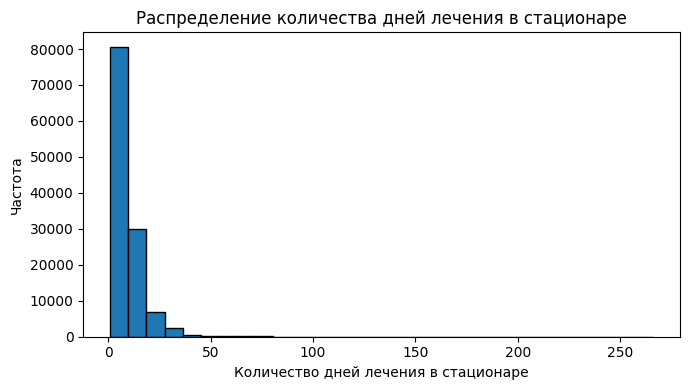

In [121]:
plt.figure(figsize=(7, 4))
plt.hist(
    hospital['bed_days'],
    bins=30,
    edgecolor='black'
)
plt.xlabel("Количество дней лечения в стационаре")
plt.ylabel("Частота")
plt.title("Распределение количества дней лечения в стационаре")
plt.tight_layout()
plt.show()

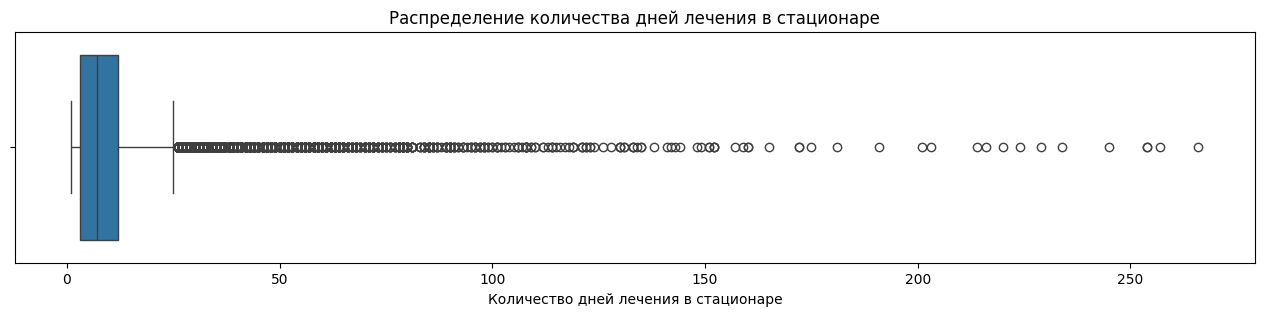

In [122]:
plt.figure(figsize=(16, 3))
sns.boxplot(x=hospital['bed_days'])

plt.xlabel("Количество дней лечения в стационаре")
plt.title("Распределение количества дней лечения в стационаре")

plt.show()

In [123]:
# Описательные статистики длительности госпитализации
bed_stats = hospital['bed_days'].describe()
iqr = bed_stats['75%'] - bed_stats['25%']
bed_stats, iqr

(count    120836.000000
 mean          8.728508
 std           8.765610
 min           1.000000
 25%           3.000000
 50%           7.000000
 75%          12.000000
 max         266.000000
 Name: bed_days, dtype: float64,
 np.float64(9.0))

- Медианная длительность госпитализации составляет 7 дней: половина пациентов проводит в стационаре не больше недели.
- Среднее значение равно 8.7 дня и выше медианы, что указывает на правостороннее смещение распределения из‑за редких, но очень долгих госпитализаций.
- Четверть пациентов (25‑й перцентиль) лежит не более 3 дней, что говорит о большом числе краткосрочных госпитализаций.
- Максимальная длительность достигает 266 дней, что отражает наличие отдельных крайне длительных случаев лечения.

###3.2. Средняя длительность по отделениям (топ‑10)  

In [124]:
# Средняя длительность лечения по отделениям
dept_stay = (
    hospital
    .groupby('dept')['bed_days']
    .mean()
    .sort_values(ascending=False)
)

dept_stay.head(10)

/tmp/ipykernel_1831/1055331631.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,bed_days
dept,
Отделение анестезиологии-реанимации,45.179487
ПЦ ОАРИТН №1 (новорожденных),28.723214
ПЦ Отделение Анестезиологии-реанимации для детей с кардиохирургической патологией,26.438095
ПЦ Отделение патологии новорожденных и детей грудного возраста,22.098196
ПЦ Отделение вспомогательных репродуктивных технологий ДС,21.297802
Дневной стационар Кожно-венерологического отделения,14.027322
Дневной стационар Гастроэнтерологического отделения,13.339286
Микрохирургическое отделение,13.293007
Педиатрическое отделение №1,12.824642


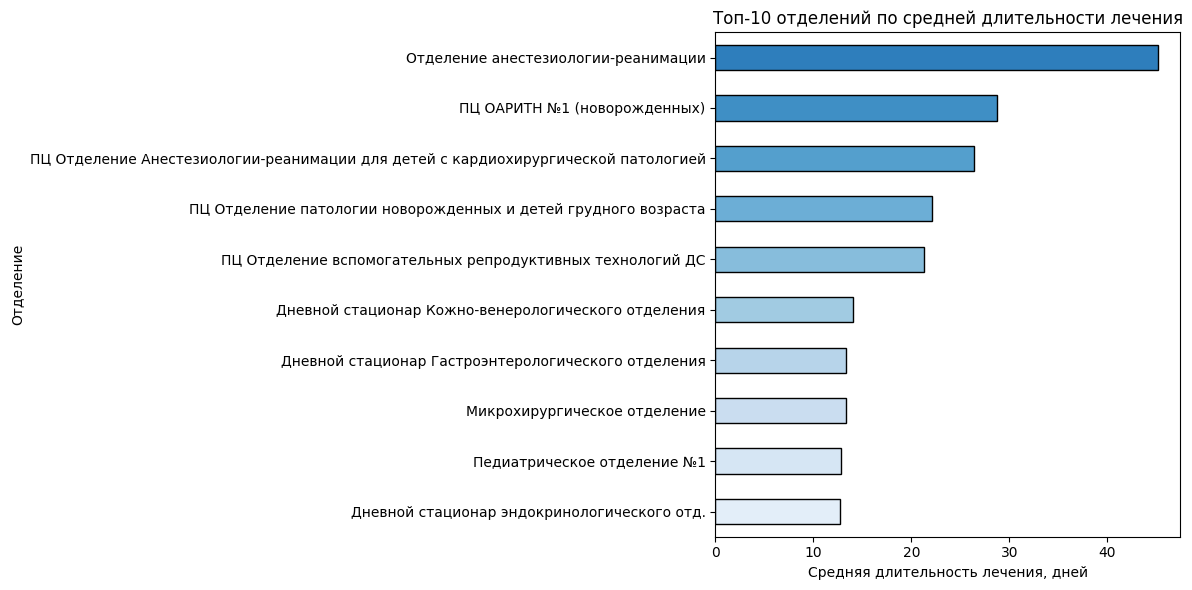

In [125]:
# Топ‑10 отделений по средней длительности лечения с градиентом синего
top10 = dept_stay.head(10)

plt.figure(figsize=(12, 6))

# Генерируем градиент цветов от тёмно‑синего к светло‑синему
colors = plt.cm.Blues_r(
    np.linspace(0.3, 0.9, len(top10))
)

top10.plot(
    kind='barh',
    color=colors,
    edgecolor='black'
)

plt.xlabel("Средняя длительность лечения, дней")
plt.ylabel("Отделение")
plt.title("Топ‑10 отделений по средней длительности лечения")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

- Дольше всего пациенты лежат в отделении анестезиологии‑реанимации, ПЦ ОАРИТН №1 для новорождённых и кардиохирургической реанимации для детей, что отражает тяжесть состояний и сложность лечения.
- Краткосрочные госпитализации (< 5 дней) характерны для ПЦ ОАРИТ №2 для беременных, рожениц и родильниц и ПЭМП ДПО, где, вероятно, проводится короткое наблюдение или диагностика.

###3.3. Динамика количества поступлений по месяцам и годам

In [126]:
hospital['year'] = hospital['income_date'].dt.year
hospital['month'] = hospital['income_date'].dt.month

In [127]:
monthly_adm = (
    hospital
    .groupby(['year', 'month'], as_index=False)['user_id']
    .count()
    .rename(columns={'user_id': 'admissions'})
)

monthly_adm.head()

,year,month,admissions
0,2019,1,1775
1,2019,2,1927
2,2019,3,2080
3,2019,4,2205
4,2019,5,2020


In [128]:
monthly_adm['period'] = pd.to_datetime(
    dict(year=monthly_adm['year'], month=monthly_adm['month'], day=1)
)

monthly_adm.head()

,year,month,admissions,period
0,2019,1,1775,2019-01-01
1,2019,2,1927,2019-02-01
2,2019,3,2080,2019-03-01
3,2019,4,2205,2019-04-01
4,2019,5,2020,2019-05-01


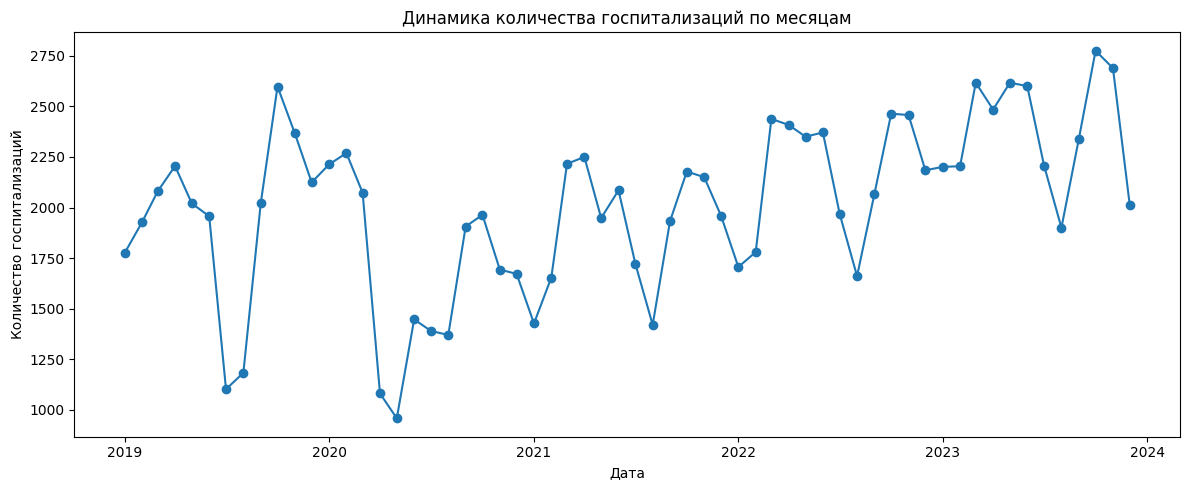

In [129]:
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_adm['period'],
    monthly_adm['admissions'],
    marker='o'
)
plt.xlabel('Дата')
plt.ylabel('Количество госпитализаций')
plt.title('Динамика количества госпитализаций по месяцам')
plt.tight_layout()
plt.show()

По данным видно, что в **2019** году количество госпитализаций постепенно растёт: с 1775 в январе до 2205 в апреле, после чего в мае наблюдается небольшое снижение до 2020 случаев. Такая динамика может отражать сезонные колебания нагрузки на стационар: постепенное увеличение к весне и последующее лёгкое снижение в начале лета; в дальнейшем при анализе 2020 года стоит учитывать возможное влияние пандемии COVID‑19, которая во многих странах приводила к сокращению плановых госпитализаций и изменению структуры обращений.



## 4. Проверка статистических гипотез
---

###4.1. Проверка отклонения от стандартного срока 7 дней  

Сформулируем гипотезы:

- **\(H_0\)**: средняя длительность госпитализации в больнице равна 7 дням (соответствует стандарту).
- **\(H_1\)**: средняя длительность госпитализации в больнице не равна 7 дням.

Для проверки используем одновыборочный t‑тест (`scipy.stats.ttest_1samp`), сравнивая среднее значение переменной `bed_days` с ожидаемым значением 7 при уровне значимости \(alpha = 0.05).  
Если p‑значение окажется меньше 0.05, мы отвергаем нулевую гипотезу и считаем, что фактическая средняя длительность госпитализации статистически значимо отличается от 7 дней.

In [130]:
expected_mean_time = 7      # стандартный срок госпитализации
alpha = 0.05                # уровень значимости

results = st.ttest_1samp(
    hospital['bed_days'],
    expected_mean_time,
    alternative='two-sided'
)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 0.0
Отвергаем нулевую гипотезу


Полученное p‑значение практически равно 0 и значительно меньше выбранного уровня значимости 0.05, поэтому нулевая гипотеза отвергается. Это означает, что фактическая средняя длительность госпитализации статистически значимо отличается от стандартного срока в 7 дней.

###4.2. Проверка гипотезы «средняя длительность > 10 дней»  

Теперь медицинский отдел хочет проверить, превышает ли средняя длительность госпитализации пациентов 10 дней. Для этого сформулируем одностороннюю статистическую гипотезу.

- **H₀**: средняя длительность госпитализации в больницах равна 10 дням.
- **H₁**: средняя длительность госпитализации в больницах больше 10 дней.

Для проверки используем одновыборочный t‑тест (`scipy.stats.ttest_1samp`) по переменной `bed_days`, сравнивая её среднее с пороговым значением 10 при уровне значимости α = 0.05 и параметре `alternative='greater'`. Если p‑значение окажется меньше 0.05, мы отвергнем нулевую гипотезу и сделаем вывод, что средняя длительность статистически значимо превышает 10 дней.

In [131]:
threshold = 10      # порог для средней длительности
alpha = 0.05        # уровень значимости

results_gt10 = st.ttest_1samp(
    hospital['bed_days'],
    threshold,
    alternative='greater'  # H1: mean > 10
)

print('p-значение:', results_gt10.pvalue)

if results_gt10.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 1.0
Не получилось отвергнуть нулевую гипотезу


- Дополнительно, ранее было рассчитано фактическое среднее значение длительности госпитализации — около 8.73 дня, что меньше проверяемого порога в 10 дней.
- При таком среднем и p‑значении, равном 1.0 и значительно превышающем уровень значимости 0.05, нулевая гипотеза не отвергается. Это означает, что у нас нет статистических оснований утверждать, что средняя длительность госпитализации пациентов значимо превышает 10 дней.

###4.3. Сравнение длительности лечения у плановых и экстренных пациентов

### 4.3. Сравнение длительности лечения у плановых и экстренных пациентов

Задача — проверить, различается ли средняя продолжительность лечения в стационаре между плановыми и экстренными пациентами. Для этого разобьём данные на две группы по признаку `is_plan` и сравним среднее количество койко‑дней в каждой из них.

Сформулируем гипотезы:

- **H₀**: средняя длительность госпитализации у плановых и экстренных пациентов **одинакова**.
- **H₁**: средняя длительность госпитализации у плановых и экстренных пациентов **различается**.

Из выборки получаем:

- средняя длительность лечения плановых пациентов: примерно 9.72 дня;
- средняя длительность лечения экстренных пациентов: примерно 6.25 дня;
- разница — около 3.5 дня в пользу более короткого пребывания у экстренных пациентов.

Для формальной проверки используем t‑тест для двух независимых выборок (`scipy.stats.ttest_ind`) с параметром `equal_var=False` (вариант Уэлча), чтобы не предполагать равенство дисперсий. При p‑значении, близком к 0 и меньше 0.05, мы отвергаем нулевую гипотезу и заключаем, что средняя длительность лечения статистически значимо различается между плановыми и экстренными пациентами.

In [132]:
# Формируем группы по типу поступления
plan_group = hospital[hospital["is_plan"] == "Плановая"]["bed_days"]
urgent_group = hospital[hospital["is_plan"] == "Экстренная"]["bed_days"]

# Смотрим средние значения
print("Средняя длительность (плановые):", plan_group.mean())
print("Средняя длительность (экстренные):", urgent_group.mean())

# Двухвыборочный t-тест
alpha = 0.05

results_two_sample = st.ttest_ind(
    plan_group,
    urgent_group,
    equal_var=False,     # не предполагаем равенство дисперсий
    alternative='two-sided'  # H1: средние не равны
)

print("p-значение:", results_two_sample.pvalue)

if results_two_sample.pvalue < alpha:
    print("Отвергаем H0: средняя длительность различается между группами")
else:
    print("Не получилось отвергнуть H0: статистически значимых различий не найдено")

Средняя длительность (плановые): 9.716638313138677
Средняя длительность (экстренные): 6.248380631481105
p-значение: 0.0
Отвергаем H0: средняя длительность различается между группами


По результатам теста p‑значение оказывается практически равным 0 и намного меньше 0.05, поэтому нулевая гипотеза отвергается. Это означает, что разница во времени пребывания между плановыми и экстренными пациентами статистически значима: плановые пациенты в среднем лечатся дольше примерно на 3–4 дня.

## 5. Выводы
---

###5.1. Обзор проделанной работы

- Проанализированы данные о **120 тыс.** госпитализаций в федеральном медцентре: выполнена загрузка, переименование полей, анализ и обработка пропусков и дубликатов.  
- Типы данных приведены к удобному формату (даты → `datetime`, категориальные признаки → `category`), что позволило существенно сократить использование памяти и упростить дальнейший анализ.  
- Проведён исследовательский анализ длительности госпитализации: описательные статистики, распределения, топ‑10 отделений по средней длительности лечения и динамика поступлений по месяцам.  
- На заключительном этапе проверены три статистические гипотезы о средней длительности лечения и её различиях между типами госпитализации.

###5.2. Ключевые выводы

- Большинство пациентов проводят в стационаре относительно недолго: медиана — **7 дней**, четверть лежит не более 3 дней, при этом редкие очень долгие госпитализации тянут среднее до ~8.7 дня.  
- Средняя длительность госпитализации статистически значимо отличается от стандартных 7 дней, но нет оснований считать, что она превышает 10 дней, то есть текущий средний срок не создаёт устойчивого риска переполнения стационара.  
- Отделения реанимационного и неонатального профиля показывают наибольшую среднюю длительность лечения, тогда как акушерские и ряд диагностических подразделений характеризуются краткосрочными госпитализациями.  
- **Плановые пациенты в среднем лежат заметно дольше экстренных** (примерно 9.7 против 6.2 дня), и это различие статистически значимо по результатам двухвыборочного t‑теста.

###5.3. Рекомендации для заказчика

- При планировании коечного фонда выделять отдельный фокус на отделения с высокой средней длительностью лечения (реанимации, неонатология, сложная хирургия), закладывая увеличенный срок пребывания в моделях загрузки.  
- Для отделений с краткосрочными госпитализациями развивать практики повышения оборота коек и оптимизации маршрутов пациентов, чтобы поддерживать высокую пропускную способность.  
- Учитывать тип госпитализации (плановая/экстренная) при планировании расписаний и квот: более длительные плановые случаи не должны блокировать доступность коек для экстренной помощи.  
- **Продолжить анализ сезонности и профилей отделений**, чтобы точнее прогнозировать пики нагрузки, адаптировать штат и операционные графики, а также использовать результаты статистических тестов для настройки нормативов длительности госпитализации по различным категориям пациентов.